# Geospatial Data Science - EEPS 440/460

# Lecture 20

# Spatial Correlation

### The first law of geography: Everything is related to everything else, but near things are more related than distant things. Waldo R. Tobler 1970

---

# Reading:

### Spatial Autocorrelation:
https://mgimond.github.io/Spatial/spatial-autocorrelation.html

---

# Objectives

- Understand what **spatial autocorrelation** is and why it matters.
- Learn the concept of **semivariograms** and how they measure spatial structure.
- Apply these concepts using Elevation data in Python.
- Explore the implications of spatial correlation for machine learning.

## 1. Introduction to Spatial Autocorrelation

**Spatial autocorrelation** is a measure of how similar values are based on their spatial location. 

If values at nearby locations are more similar than those far apart, the data exhibits **positive spatial autocorrelation**.

### Why is it Important?
- Influences the accuracy of predictive spatial models.
- Violates the assumption of independent samples in many ML and AI models.
- Used in **kriging**, **spatial regression**, and **geostatistics**.

### Think About:
If we sample elevation from a mountainous region, do you expect elevation at nearby locations to be similar?

## 2. What is a Semivariogram?

A **semivariogram** is a tool to quantify how spatial autocorrelation changes with distance.

###  Mathematical Definition

$$
\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [z(x_i) - z(x_i + h)]^2
$$

Where:
- $ h $: lag distance
- $ N(h) $: number of pairs separated by $ h $
- $ z(x) $: value at location $ x $

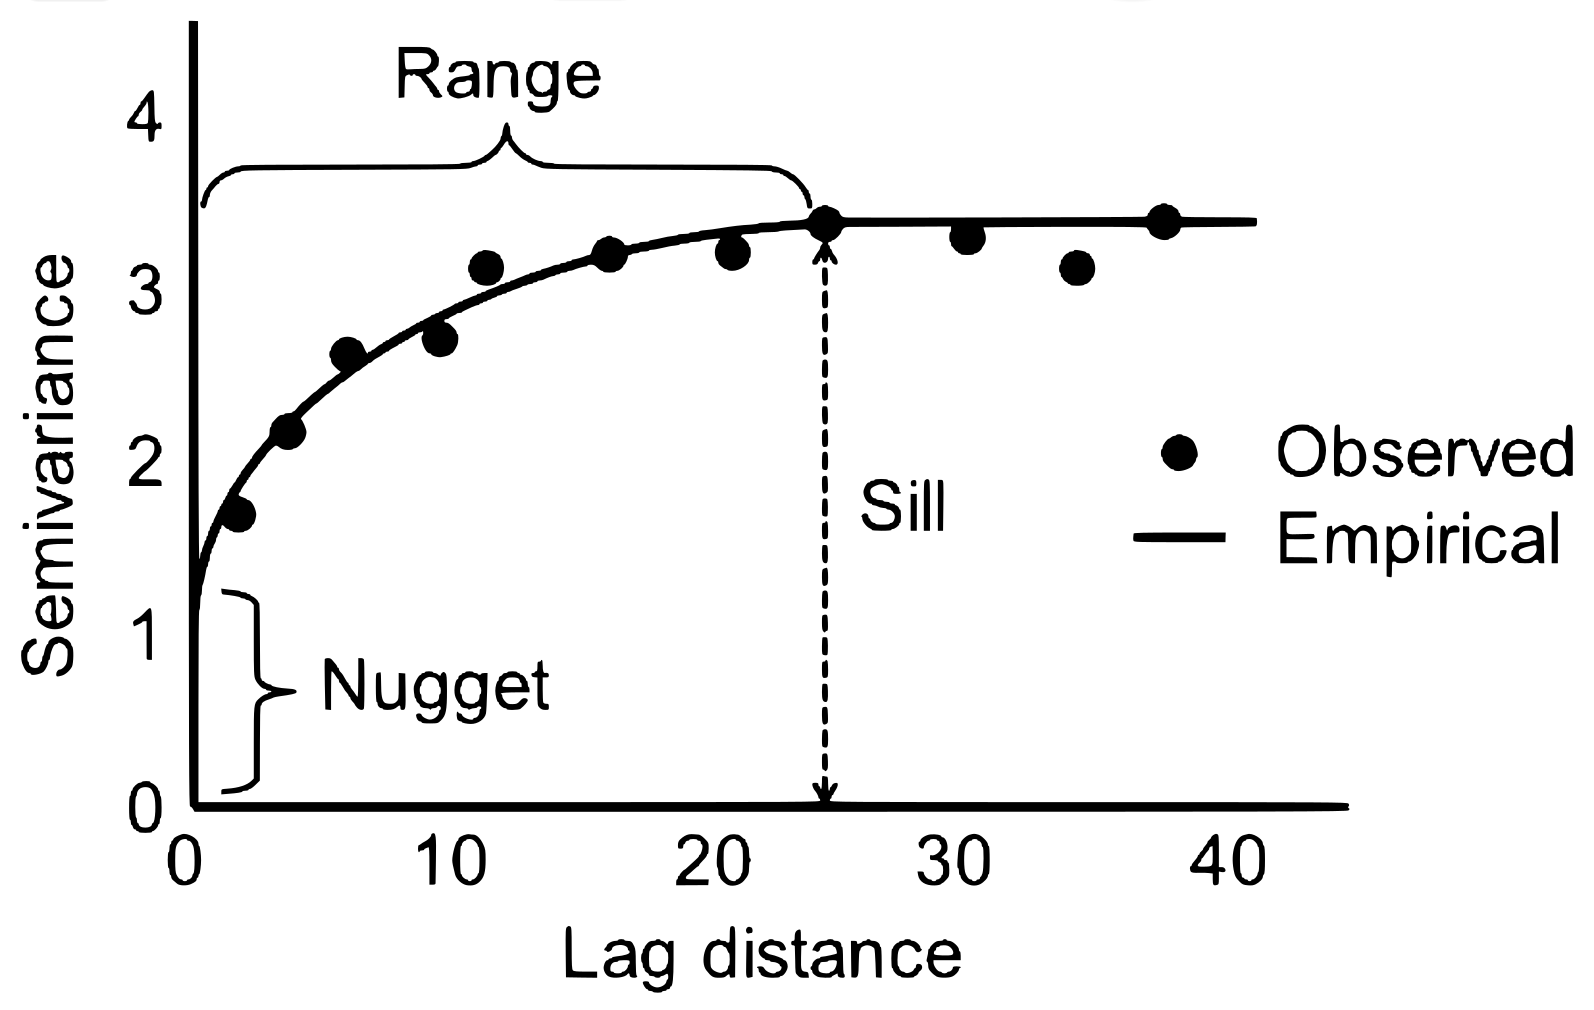

### Key Concepts
- **Nugget**: variance at very small distances.
- **Sill**: value where the variogram levels off.
- **Range**: distance beyond which data are uncorrelated.

### Short video on how the variogram is computed

https://www.youtube.com/watch?v=hxkgL6VA_Nw

# Lets look into soil data as an example

In [ ]:
import rasterio
import numpy as np

# Open the sand raster (from clustering analysis lecture) using rasterio
with rasterio.open('../Workspace/sand.tif') as src:
    data = src.read(1)

    # fill missing values with global mean (just for the sake of this example)
    data[data == src.nodata] = np.nanmean(data)
    
    # Generate a 1D array of y-coordinates (latitude) spanning from the top to the bottom of the raster
    lats = np.linspace(src.bounds.top+src.res[0]/2, src.bounds.bottom-src.res[0]/2, src.height)
    
    # Generate a 1D array of x-coordinates (longitude) spanning from the left to the right of the raster
    lons = np.linspace(src.bounds.left+src.res[0]/2, src.bounds.right-src.res[0]/2, src.width)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='terrain')
cbar = plt.colorbar()
cbar.set_label('Sand (%)', fontsize=12)
plt.title('Sand Map', fontsize=16)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Let's randomly sample n different points

In [ ]:
#Let's randomly sample n different points (10% of the domain)
nsamples = int(0.1*(lons.size*lats.size))
print('Number of samples:',nsamples)
#Randomly sample n points on the domain
np.random.seed(1)
(xs,ys) = np.meshgrid(np.arange(lons.size),np.arange(lats.size))
ipoints = np.random.choice(np.arange(lons.size*lats.size),nsamples,replace=False)
ix = xs.ravel()[ipoints]
iy = ys.ravel()[ipoints]
#Extract the points
y_points = lats[iy]
x_points = lons[ix]
#Extract the data
data_points = []
for i in range(iy.size):
    data_points.append(data[iy[i],ix[i]])
        
data_points = np.array(data_points)

In [ ]:
# scatter plot of the sampled data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
scatter = plt.scatter(ix, np.max(iy) - iy, c=data_points, s=3, cmap='terrain')
plt.colorbar(scatter, label='Sand (%)', orientation='vertical')
plt.title('Sand', fontsize=30)
plt.show()

###  Let's compute the semivariogram for our data

$$
\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [z(x_i) - z(x_i + h)]^2 = \frac{1}{N(h)} \sum_{i=1}^{N(h)} \gamma_{c}
$$

Where:
- $ h $: lag distance
- $ N(h) $: number of pairs separated by $ h $
- $ z(x) $: value at location $ x $

In [ ]:
def compute_euclidean_distances(x_points, y_points):
    # Earth's radius in meters
    R = 6371000  
    
    # Convert degrees to radians
    lat_rad = np.deg2rad(y_points)
    lon_rad = np.deg2rad(x_points)

    # Use the mean latitude to correct longitudinal distances
    avg_lat = np.mean(lat_rad)

    # Compute differences
    delta_x = (lon_rad[:, np.newaxis] - lon_rad[np.newaxis, :]) * np.cos(avg_lat)
    delta_y = lat_rad[:, np.newaxis] - lat_rad[np.newaxis, :]

    # Convert angular differences to meters
    distances = R * np.sqrt(delta_x**2 + delta_y**2)
    
    # return distances in km
    return distances/1000

def compute_gamma_c(data_points):
    # Compute the squared differences between all pairs of data points
    differences = data_points[:, np.newaxis] - data_points[np.newaxis, :]
    gamma_c = (differences ** 2) / 2
    return gamma_c

# Compute Euclidean distances from observations to observations (for n points, returns a n**2 matrix)
h = compute_euclidean_distances(x_points, y_points)

# Compute variogram cloud by comparing all points
gamma_c = compute_gamma_c(data_points)

#Reshape to 1d arrays
h = h.reshape(h.size)
gamma_c = gamma_c.reshape(gamma_c.size)

In [ ]:
plt.figure(figsize=(15,6))
#Make the scatter plot
plt.scatter(h,gamma_c,alpha=0.01)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# #Let's only consider points that are up to 10000 meters away from each other
# plt.xlim([0,10000])

plt.xlabel(r'$h_{i,j} (km)$',fontsize=40)
plt.ylabel(r'$\gamma_c($%$^2)$',fontsize=40)
plt.show()

In [ ]:
#Define delta
delta = 0.5 #km

#Define bin edges
bin_edges = np.linspace(0,100,int(100/delta+1))

#Compute the center of each bin
bin_centers = (bin_edges[1:] + bin_edges[0:-1])/2

#Compute sample semivariogram
gamma_s = []
for i in range(bin_centers.size):
    if i == 0:
        m = (h >= bin_edges[i]) & (h < bin_edges[i+1])
    else:
        m = (h > bin_edges[i]) & (h <= bin_edges[i+1])
    tmp = np.mean(gamma_c[m])
    gamma_s.append(tmp)
gamma_s = np.array(gamma_s)

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(bin_centers, gamma_s, 'o', markersize=10, label='Sample $\gamma$', color='blue')

# Add grid for better readability
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Add a legend
plt.legend(fontsize=20, loc='upper left')

# Customize ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add labels and title
plt.xlabel(r'$h \, (\mathrm{km})$', fontsize=30)
plt.ylabel(r'$\hat{\gamma} \, (\%^{2})$', fontsize=30)
plt.title('Sample Semivariogram', fontsize=35)

# Show the plot
plt.tight_layout()
plt.show()

# What would be the range, sill, and nugget in our example?

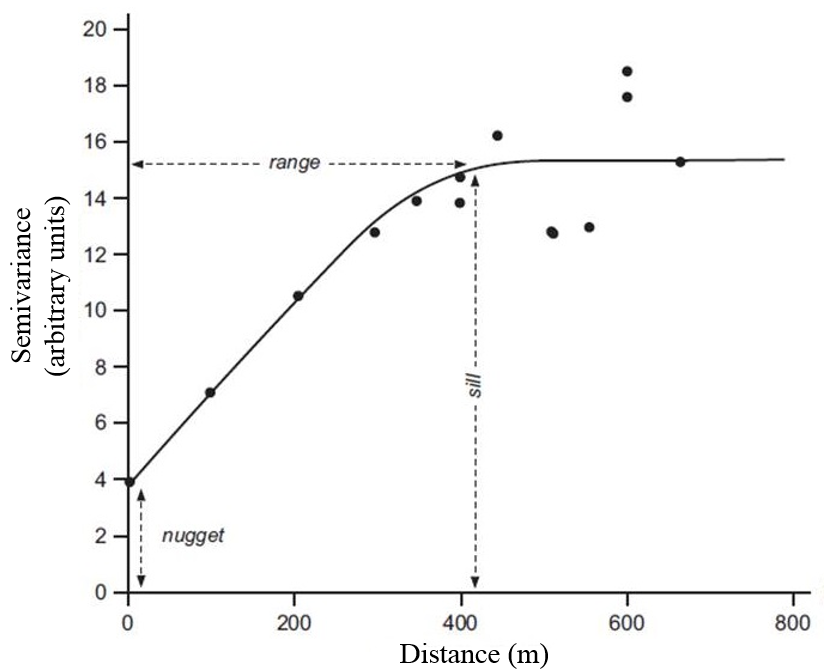

# Modeling the Semivariogram

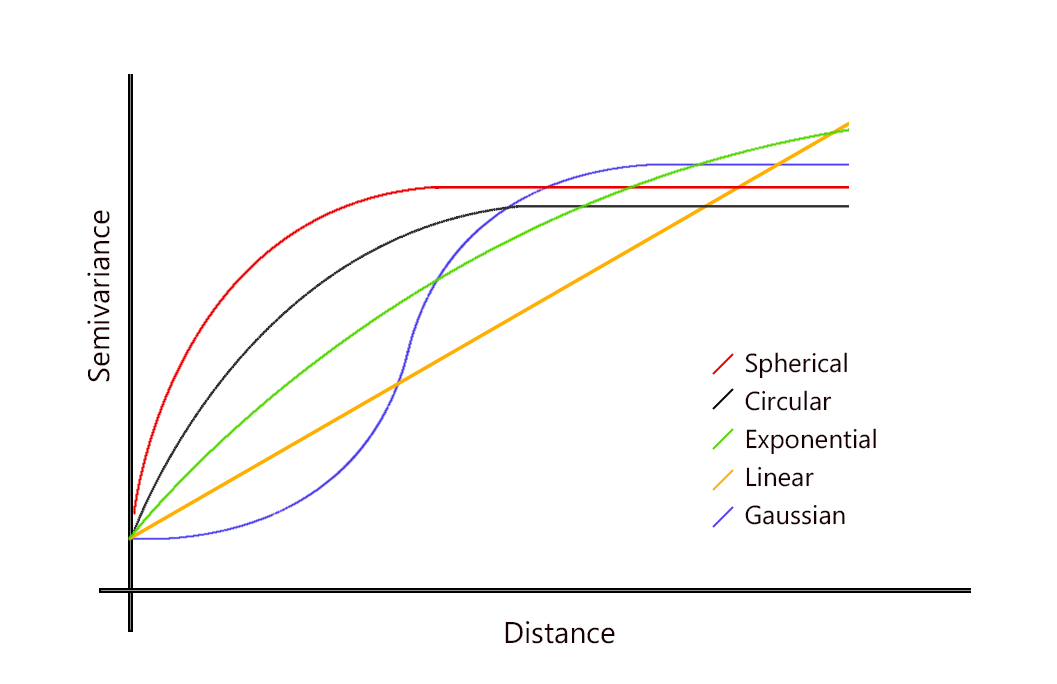

# Fit an Exponential Semivariogram

The exponential semivariogram model is defined as:

$$\gamma(h) = c\left(1 - \exp\left(-\frac{h}{\tau}\right)\right)$$

Where:
- $\gamma(h)$: Semivariance at lag distance $h$
- $c$: Sill, the maximum semivariance value
- $\tau$: Range parameter, controlling the rate of increase in semivariance with distance
- $h$: Lag distance

In [ ]:
import scipy.optimize

def exponential_semivariogram(h, c, tau):
    return c * (1 - np.exp(-h / tau))

# Fit the exponential semivariogram model to the sample semivariogram data
# bin_centers: Lag distances (in kilometers)
# gamma_s: Sample semivariance values 
# bounds: Lower and upper bounds for the parameters [c, tau]
popt, pcov = scipy.optimize.curve_fit(
    exponential_semivariogram,
    bin_centers,
    gamma_s,
    bounds=([0, 0], [30, 100])  # c in range from 0 to 30 (%^2), tau in range from 0 to 100 (km)
)

# Extract and print the fitted parameters
print('Sill (c): %.2f %%^2' % popt[0])   # Sill 
print('Range (tau): %.2f km' % popt[1])  # Range in kilometers

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(bin_centers, gamma_s, 'o', markersize=10, label='Sample $\gamma$', color='blue')
plt.plot(bin_centers, exponential_semivariogram(bin_centers,*popt), label='Modeled $\gamma$', color='orange', lw=5)

# Add grid for better readability
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=20, loc='lower right')

# Customize ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add labels and title
plt.xlabel(r'$h \, (\mathrm{km})$', fontsize=30)
plt.ylabel(r'$\hat{\gamma} \, (\%^{2})$', fontsize=30)
plt.title('Semivariogram', fontsize=35)

# Show the plot
plt.tight_layout()
plt.show()

# Relationship between semivariance and covariance
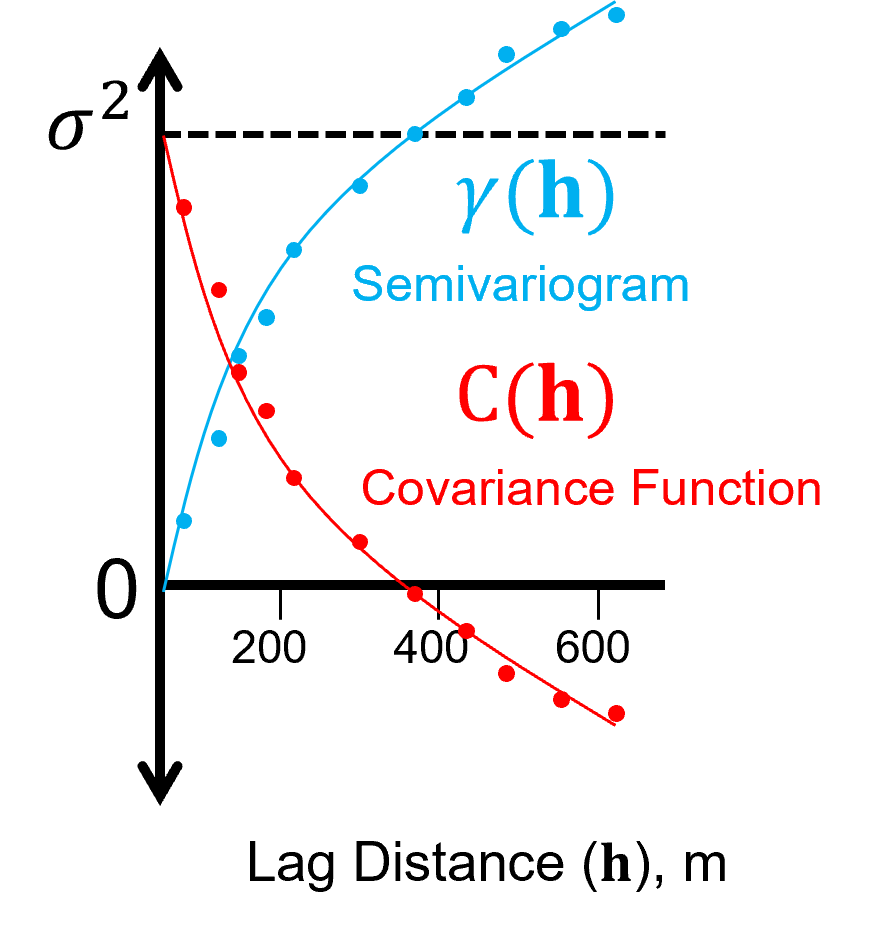


For bounded semivariograms, there is an associated covariance function. This relationship is valid when the random field $Z$ is a **second-order stationary random field**, meaning:
- The mean is constant.
- The variance is constant.
- The covariance between two points depends only on the distance between them.

This allows us to define the relationship between the semivariogram $\gamma(h)$ and the covariance function $C(h)$ as:

$$\gamma(h) = C(0) - C(h)$$

or equivalently:

$$\gamma(h) = \text{Var}(Z) - \text{Cov}(Z_i, Z_j)$$

### Key Insight:
If we know the model semivariogram, we can derive the model covariance function, and vice versa.

---

# Exponential Semivariogram vs. Exponential Covariance Function

The **exponential semivariogram model** is defined as:

$$\gamma(h) = c\left(1 - \exp\left(-\frac{h}{\tau}\right)\right)$$

The corresponding **exponential covariance function** is:

$$C(h) = c\left(\text{exp}\left(-\frac{h}{\tau}\right)\right)$$

### Parameters:
- $c$: Sill (maximum semivariance value).
- $\tau$: Range parameter (controls the rate of increase in semivariance with distance).
- $h$: Lag distance.

### Summary:
The semivariogram and covariance function are mathematically linked, and understanding one provides insight into the other.

In [ ]:
def exponential_covariance(h,c,tau):
    return c * (np.exp(-h/tau))


plt.figure(figsize=(16, 5))
plt.plot(bin_centers, gamma_s, 'o', markersize=10, label='Sample $\gamma$', color='blue')
plt.plot(bin_centers, exponential_semivariogram(bin_centers,*popt), label='Modeled $\gamma$', color='orange', lw=5)
plt.plot(bin_centers, exponential_covariance(bin_centers,*popt), label='Modeled $COV$', color='green', lw=5)

# Add grid for better readability
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=20, loc='lower right')

# Customize ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Add labels and title
plt.xlabel(r'$h \, (\mathrm{km})$', fontsize=30)
plt.ylabel(r'$\hat{\gamma} \, (\%^{2})$', fontsize=30)
plt.title('Semivariogram', fontsize=35)

# Show the plot
plt.tight_layout()
plt.show()

# Leveraging Spatial Covariance for Spatial Interpolation

Spatial covariance is a powerful concept that allows us to predict values at unobserved locations by leveraging the spatial correlation structure of the data. Below are some advanced techniques that utilize spatial covariance for interpolation:

### 1. **Kriging Interpolation**
Kriging is a geostatistical method used to predict values at unobserved locations. It leverages spatial correlation structures to provide the best linear unbiased predictions.

### 2. **Block Kriging (Areal Means)**
Block Kriging extends traditional Kriging techniques to predict average values over specific areas or blocks, rather than individual points. This is particularly useful for applications requiring aggregated spatial predictions.

### 3. **Conditional Simulation**
Conditional simulation generates multiple plausible realizations of spatial fields that honor observed data and modeled spatial correlations. This is especially useful for assessing uncertainty in spatial predictions.

### For more details refer to the comprehensive guide on spatial interpolation:  
[Spatial Interpolation - r-spatial.org](https://r-spatial.org/book/12-Interpolation.html)

---


We learned about geospatial data is spatially correlated and how to quantify it
# How does this impact how I train my statistical models?

# Let's go back to our example from the random forest class

In [ ]:
#Read in all the data
import rasterio
%matplotlib inline
import matplotlib.pyplot as plt
vars = ['WELD_Band1_TOA_REF','WELD_Band2_TOA_REF','WELD_Band3_TOA_REF','WELD_Band4_TOA_REF',
        'WELD_Band5_TOA_REF','WELD_Band61_TOA_BT','WELD_Band62_TOA_BT','WELD_Band7_TOA_REF',
        'WELD_NDVI_TOA','nlcd_land_cover','nlcd_impervious','nlcd_tree_canopy']
data = {}
for var in vars:
    src = rasterio.open('../Workspace/%s.tif' % var)
    data[var] = src.read(1)
    src.close()

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import numpy as np
src = rasterio.open("../Workspace/nlcd_land_cover.tif")
data['nlcd_land_cover'] = src.read(1)

# colormap determination and setting bounds
with rasterio.open("../Workspace/nlcd_land_cover.tif") as r:
    cmap_in = r.colormap(1)
    cmap1 = [[int(jj) for jj in cmap_in[ii]] for ii in cmap_in]
    cmap_in = [[float(jj)/255.0 for jj in cmap_in[ii]] for ii in cmap_in]
    indx_list = np.unique(data['nlcd_land_cover'])
    r_cmap = []    
    for ii in indx_list:
        r_cmap.append(cmap_in[ii])
    raster_cmap = ListedColormap(r_cmap) # defining the NLCD specific color map
    norm = mpl.colors.BoundaryNorm(indx_list, raster_cmap.N) # specifying colors based on num. unique points
    
plt.figure(figsize=(10,10))
plt.imshow(data['nlcd_land_cover'],cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.show()
src.close()

# Create the database for model training

In [ ]:
import sklearn.ensemble

variable = 'nlcd_land_cover' # target variable, think as our y variable

#Bring in the data to create the predictor matrix X
X = []
feature_names = []
# Lets flatten from 2D to 1D and store all the other variables in X
for var in data:
    if var == variable:
        continue
    tmp = data[var].reshape(data[var].size)
    X.append(tmp)
    feature_names.append(var)
X = np.array(X).T # transpose to have the right shape

#Define the target variable and flatten from 2D to 1D
Y = data[variable].reshape(data[variable].size)

In [ ]:
#Draw 2500 random samples to define the training dataset
nsamples = 2500
np.random.seed(1)
idx = np.random.choice(Y.size,nsamples)
# create the boolean mask with the indices
m = np.zeros(Y.size).astype(int)
m[idx] = 1
m = m.astype(np.bool)

#Create the training dataset
X_train = X[m]
Y_train = Y[m]
#Create the testing dataset     
X_test = X[~m]
Y_test = Y[~m]

In [ ]:
# Create the x_points and y_points from the NLCD dataset
with rasterio.open("../Workspace/nlcd_land_cover.tif") as r:
    lats = np.linspace(r.bounds.top+r.res[0]/2, r.bounds.bottom-r.res[0]/2, r.height)
    lons = np.linspace(r.bounds.left+r.res[0]/2, r.bounds.right-r.res[0]/2, r.width)
    xs,ys = np.meshgrid(np.arange(lons.size),np.arange(lats.size))
    x_points = lons[xs.ravel()]
    y_points = lats[ys.ravel()]

# Let's also get the x_points and y_points for the training and testing datasets
x_points_train = x_points[m]
y_points_train = y_points[m]
x_points_test = x_points[~m]
y_points_test = y_points[~m]

# Random Forest

In [ ]:
import sklearn.ensemble
#Random forest
clf = sklearn.ensemble.RandomForestClassifier(n_estimators=100)
#Fit the random forest with the training samples
clf = clf.fit(X[m,:],Y[m])
#Assess the accuracy using the validation dataset (everything not in the training dataset ~m)
print('Accuracy:',clf.score(X[~m,:],Y[~m]))
#Predict the classes at each pixel
Y_pred = clf.predict(X[~m,:])
#Make the figure to compare the original to the reproduced
plt.figure(figsize=(16,28))
plt.subplot(122)
plt.title('Reproduced - Random Forest',fontsize=25)
plt.imshow(clf.predict(X).reshape(data['nlcd_land_cover'].shape), cmap=raster_cmap, norm=norm)
plt.xticks([])
plt.yticks([])
plt.subplot(121)
plt.title('Original',fontsize=25)
plt.imshow(data['nlcd_land_cover'],cmap=raster_cmap,norm=norm)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# For a given testing point, calculate the minumum distance to all training points
def compute_minimmal_euclidean_distances(x_points_i, y_points_i, x_points_train, y_points_train):
    # Earth's radius in meters
    R = 6371000  
    
    # Convert degrees to radians
    lat_rad = np.deg2rad(y_points_i)
    lon_rad = np.deg2rad(x_points_i)
    lat_train_rad = np.deg2rad(y_points_train)
    lon_train_rad = np.deg2rad(x_points_train)

    # Use the mean latitude to correct longitudinal distances
    avg_lat = np.mean(lat_rad)

    # Compute differences
    delta_x = (lon_train_rad - lon_rad) * np.cos(avg_lat)
    delta_y = lat_train_rad - lat_rad

    # Convert angular differences to meters
    distances = R * np.sqrt(delta_x**2 + delta_y**2)
    
    # return the minimum distance in meters
    return np.min(distances)

# Loop over each testing point to calculate the minimum distance to all training points and the accuracy
distances = []
accuracies = [] 
for i in range(x_points_test.size):
    # Compute the minimum distance to all training points
    distance = compute_minimmal_euclidean_distances(x_points_test[i], y_points_test[i], x_points_train, y_points_train)
    distances.append(distance)
    
    # Compute the accuracy for the testing point
    accuracy = (Y_test[i] == Y_pred[i])
    accuracies.append(accuracy)

distances = np.array(distances)
accuracies = np.array(accuracies)

In [ ]:
# Compute the mean accuracy for bins at each 50m of distance
bin_edges = np.arange(0, np.max(distances) + 50, 50)
binned_distances = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers
binned_accuracies = []
binned_count = []

for i in range(len(bin_edges) - 1):
    mask = (distances >= bin_edges[i]) & (distances < bin_edges[i + 1])
    count = np.sum(mask)
    binned_accuracies.append(np.mean(accuracies[mask]) if count > 10 else np.nan)
    binned_count.append(count if count > 10 else np.nan)

binned_accuracies = np.array(binned_accuracies)
binned_count = np.array(binned_count)

In [ ]:
# Plot the mean accuracy as a function of binned distance
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot mean accuracy on the left y-axis
ax1.plot(binned_distances, binned_accuracies, '-o', label='Mean Accuracy per Bin', color='blue')
ax1.axhline(y=np.nanmean(accuracies), color='red', linestyle='--', label='Mean Accuracy')
ax1.set_xlabel('Distance from Training Data (m)', fontsize=14)
ax1.set_ylabel('Classification Accuracy', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Create a second y-axis for binned count
ax2 = ax1.twinx()
ax2.plot(binned_distances, binned_count, '-s', color='orange')
ax2.set_ylabel('Testing samples per bin', fontsize=14, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.legend(fontsize=12)
plt.show()

## Challenges of Spatially Correlated Data in Machine Learning, Deep Learning, and Data Science

- **Violation of i.i.d. Assumption**: Many machine learning and deep learning models (e.g., Random Forests, SVMs, Neural Networks) assume that data points are **independent and identically distributed (i.i.d.)**. Spatially correlated data violates this assumption, as nearby observations are often more similar than distant ones.

- **Bias in Accuracy Metrics**: Standard train-test splits assume independence between training and testing data. Spatial autocorrelation can lead to **data leakage**, where the test set is not truly independent of the training set, resulting in **overestimated accuracy metrics**.

- **Overfitting to Spatial Patterns**: Models may inadvertently learn spatial clusters or patterns rather than the underlying relationships in the data. This can lead to **poor generalization** when applied to new, spatially distinct regions.

- **Misleading Feature Importance**: Spatial correlation can inflate the importance of certain features, leading to **biased interpretations** of model outputs.

- **Challenges in Model Validation**: Traditional cross-validation techniques may fail to account for spatial dependencies, requiring specialized approaches like **spatial cross-validation** or **block cross-validation**.

- **Impact on Deep Learning**: In deep learning, convolutional neural networks (CNNs) and other architectures may struggle with spatially autocorrelated data if not properly designed, leading to **spatial overfitting** or **biased feature extraction**.

- **Implications for Decision-Making**: In data science applications, decisions based on models trained on spatially correlated data may be unreliable, especially when extrapolating to new areas.

### Key Takeaway:
To address these challenges, it is crucial to incorporate spatial awareness into data preprocessing, model design, and validation workflows. Techniques such as **spatial cross-validation**, **spatial feature engineering**, and **geostatistical modeling** can help mitigate the effects of spatial autocorrelation.
